In [1]:
import os

# Must be set before any numerical library is imported
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"       # If using Intel MKL
os.environ["NUMEXPR_NUM_THREADS"] = "1"   # If using NumExpr
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"  # macOS Accelerate framework

# For Latex (get path from `which latex`)
latex_path = "/Library/TeX/texbin"
os.environ["PATH"] = latex_path+":" + os.environ["PATH"]

import numpy as np
import scipy as sp
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from scipy.stats import multivariate_normal,norm
from collections import defaultdict
import warnings
import sklearn.exceptions
from scipy.special import erfinv
from sklearn.metrics import precision_score, recall_score, f1_score
from tqdm.notebook import tqdm
from types import SimpleNamespace
from _util import *

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath} \usepackage{amssymb}"
})

warnings.filterwarnings("ignore", category=sklearn.exceptions.ConvergenceWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

np.set_printoptions(edgeitems=30, linewidth=100000, formatter=dict(float=lambda x: "%.3g" % x))
make_plot = lambda n,m,s=[1,1],sharex=False, sharey=False: plt.subplots(n,m,figsize=(m*3*s[0],n*2.5*s[1]),squeeze=False,layout='tight',sharex=sharex, sharey=sharey)


# Fig 1

Figure size (width x height in pixels): [7.2 2.5] 0.34722222222222227


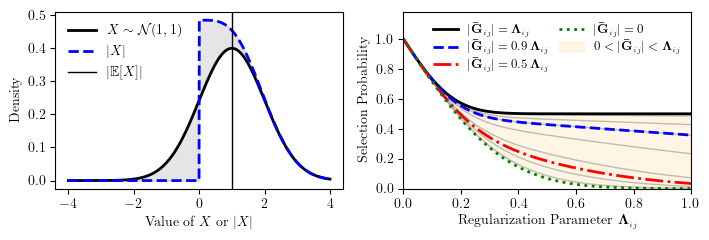

In [2]:
fig, axs = make_plot(1,2,s=[1.2,1],sharex=False, sharey=False)

#########################
#########################
inx = 0
#########################
#########################
mu = 1
sigma = 1
x = np.linspace(-4, 4, 1000)

pdf_normal = sp.stats.norm.pdf(x, mu, sigma)
c = abs(mu / sigma)

pdf_folded  = sp.stats.foldnorm.pdf(x, c, scale=sigma)
mean_folded = sp.stats.foldnorm.mean(c, scale=sigma)

# Normal distribution
axs[0,inx].plot(x, pdf_normal, label=r"$X\sim\mathcal{N}(1,1)$", color="black",linestyle="-",linewidth=2)
axs[0,inx].fill_between(x[x < 0], pdf_normal[x < 0], color='black', alpha=0.1)
axs[0,inx].plot(x, pdf_folded, label=r"$|X|$", color="blue",linestyle="--",linewidth=2)

# Highlighting how negative side maps to positive side in folded normal
axs[0,inx].fill_between(x[x>0],pdf_folded[x > 0], pdf_normal[x > 0], color='black', alpha=0.1)

# Mean lines
axs[0,inx].axvline(mu, color='black', label=r"$|\mathbb{E}[X]|$",linestyle="-",linewidth=1)
#axs[0,inx].axvline(mean_folded, color='blue', label=r"$\mathbb{E}[|X|]$",linestyle="--",linewidth=1)

axs[0, inx].set_xlabel(r'Value of $X$ or $|X|$')
axs[0, inx].set_ylabel(r'Density')
axs[0, inx].legend(loc='upper left',frameon=False,fontsize=10)

#########################
#########################
inx = inx + 1
#########################
#########################
alpha_set = [0.0, 0.2, 0.4, 0.6, 0.8, 0.90, 0.95, 0.99, 1.0]
v = 1.5
k = 20
f = lambda L, alpha: 1 - 0.5 * (
    sp.special.erf((L - alpha * L) / np.sqrt(2 * v / k)) +
    sp.special.erf((L + alpha * L) / np.sqrt(2 * v / k))
)

# Assume axs and inx are already defined
x = np.linspace(0, 1, 1000)

for alpha in alpha_set[1:-1]:
    y = f(x, alpha)
    axs[0, inx].plot(x, y, linestyle='-', linewidth=1, color='gray', alpha=0.5)

axs[0, inx].plot(x, f(x, 1.0), label=r"$|\mathbf{\bar{G}}_{\scriptscriptstyle{ij}}| = \mathbf{\Lambda}_{\scriptscriptstyle{ij}}$",          color="black", linestyle="-", linewidth=2)
axs[0, inx].plot(x, f(x, 0.9), label=r"$|\mathbf{\bar{G}}_{\scriptscriptstyle{ij}}| = 0.9 \, \mathbf{\Lambda}_{\scriptscriptstyle{ij}}$",color="blue", linestyle="--", linewidth=2)
axs[0, inx].plot(x, f(x, 0.5), label=r"$|\mathbf{\bar{G}}_{\scriptscriptstyle{ij}}| = 0.5 \, \mathbf{\Lambda}_{\scriptscriptstyle{ij}}$",      color="red", linestyle="-.", linewidth=2)
axs[0, inx].plot(x, f(x, 0.0), label=r"$|\mathbf{\bar{G}}_{\scriptscriptstyle{ij}}| = 0$",color="green", linestyle=":", linewidth=2)
axs[0, inx].fill_between(x, f(x, 0.0), f(x, 1.0),color='orange', alpha=0.1,label=r"$0<|\mathbf{\bar{G}}_{\scriptscriptstyle{ij}}|<\mathbf{\Lambda}_{\scriptscriptstyle{ij}}$")

axs[0, inx].set_ylabel(r"Selection Probability")
axs[0, inx].set_xlabel(r"Regularization Parameter $\mathbf{\Lambda}_{\scriptscriptstyle{ij}}$")

axs[0, inx].set_ylim([0, 1.18])
axs[0, inx].set_xlim([0, np.max(x)])
axs[0, inx].legend(loc='upper right', frameon=False, fontsize=9, ncol=2,labelspacing=0.3,columnspacing=0.8)

fig.savefig("fig_1.png", dpi=300)

fig_size_pixels = fig.get_size_inches()
print("Figure size (width x height in pixels):", fig_size_pixels, fig_size_pixels[1] / fig_size_pixels[0])

# Fig 2

Gamma is set as is !! 0.01
- gamma: 0.01, c: 30.0, p: 128, n: 2560 n/k: 2.0, nnzpriC: 10.21875  ||iC||: 16.411792573773614 ||C||: 13.604348266631623 
num nnzpr = 10.21875
Gamma is set as is !! 0.1
- gamma: 0.1, c: 30.0, p: 128, n: 2560 n/k: 2.0, nnzpriC: 17.84375  ||iC||: 17.403294407496652 ||C||: 13.931343550760378 
num nnzpr = 17.84375
Gamma is set as is !! 0.2
- gamma: 0.2, c: 30.0, p: 128, n: 2560 n/k: 2.0, nnzpriC: 27.484375  ||iC||: 17.956954592192005 ||C||: 14.091604601448852 
num nnzpr = 27.484375
Gamma is set as is !! 1e-06
- gamma: 1e-06, c: 16.0, p: 32, n: 16 n/k: 2.0, nnzpriC: 1.0  ||iC||: 7.846394321162234 ||C||: 4.989804049112361 
Gamma is set as is !! 0.009778666666666665
- gamma: 0.009778666666666665, c: 16.0, p: 32, n: 16 n/k: 2.0, nnzpriC: 3.5625  ||iC||: 8.062087199957633 ||C||: 5.033462637751336 
Gamma is set as is !! 0.019556333333333332
- gamma: 0.019556333333333332, c: 16.0, p: 32, n: 16 n/k: 2.0, nnzpriC: 4.9375  ||iC||: 8.378261223595002 ||C||: 5.11100346857012

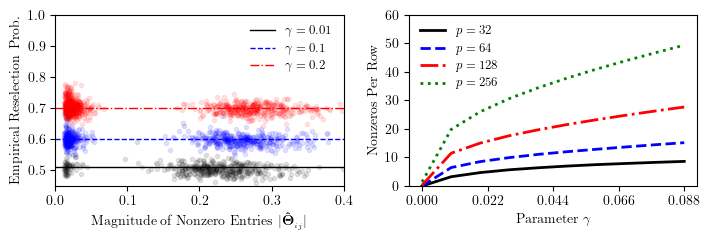

In [3]:
def test1(p=128, N=100, gamma=1/100, data_method='cluster'):

    n = int(p*20)
    k = int(n/2)

    # Precompute covariance and data
    iC_true, C_true = make_cov(p, data_type=data_method, seed=1)
    Y = make_samples(cov=C_true, n=n, seed=1)
    Y, _, _ = normalize_data(Y)
    S = np.cov(Y, bias=True)

    # Aquic result
    res_aquic = compute_aquic(Y, k=k, gamma=gamma, clip_gamma=False)
    iC = res_aquic.iC
    C  = res_aquic.C

    print("num nnzpr =", np.count_nonzero(iC) / p)

    # Precompute threshold matrix L
    diagS = np.diagonal(S)
    V = S**2 + np.outer(diagS, diagS)
    L = sp.special.erfinv(1.0 - 2.0 * gamma) / 2.0 * np.sqrt(2.0 * V / k)
    np.fill_diagonal(L, 1e-12)

    # Vectorized probability matrix P
    P = np.zeros((p, p))
    for i in range(N):
        
        inx_k = np.random.choice(int(n), size=int(k), replace=True)
        Y_k = Y[:, inx_k]
        S_k = np.cov(Y_k, bias=True)
        G_k = S_k - C
        np.fill_diagonal(G_k, 0.0)
        P += (np.abs(G_k) >= L)

    P /= N

    mask_nnz  = iC != 0
    mask_triu = np.triu(np.ones((p, p), dtype=bool), k=1)
    pr_nnz = P[mask_nnz & mask_triu].tolist()
    iC_nnz = iC[mask_nnz & mask_triu].tolist()
    pr_z   = P[~mask_nnz & mask_triu].tolist()
    iC_z   = iC[~mask_nnz & mask_triu].tolist()

    return pr_nnz, pr_z, iC_nnz, iC_z

def test2(p=128, n=None, k=None, data_method="cluster", gamma_set=None, N=100, seed=1):
  
    # Storage for results
    nnz_results = np.zeros((N, len(gamma_set)))
    iC_true, C_true = make_cov(p, data_type=data_method, seed=0)
    
    for i in range(N):
        # Generate true covariance and samples for each experiment

        Y = make_samples(cov=C_true, n=int(n), seed=i)

        for j, gamma in enumerate(gamma_set):
            res_aquic = compute_aquic(Y, k=k, gamma=gamma, clip_gamma=False)

            # Count off-diagonal nonzeros per row
            iC = res_aquic.iC.copy()
            np.fill_diagonal(iC, 0)  # Ignore diagonal
            nnz_results[i, j] = np.count_nonzero(iC) / p

    # Compute mean and std across N runs
    nnz_mean = nnz_results.mean(axis=0)
    nnz_std = nnz_results.std(axis=0)

    return nnz_mean, nnz_std


fig, axs = make_plot(1,2,s=[1.2,1],sharex=False, sharey=False)

#########################
#########################
inx = 0
#########################
#########################
p = 128
data_method = "cluster"

for color, linestyle, gamma in [ ('black', '-' , 0.01),('blue' , '--', 0.1),('red',  '-.' , 0.2)]:
    pr_nnz, pr_z, iC_nnz, iC_z = test1(p=p, gamma=gamma, data_method=data_method, N=1000)
    axs[0, inx].plot(iC_nnz,pr_nnz,linestyle='None',marker='.',color=color,alpha=0.1,label="_")
    axs[0, inx].axhline(y=(0.5 + gamma), color=color, linewidth=1, linestyle=linestyle, alpha=1, label=rf'$\gamma={gamma}$')

axs[0, inx].set_ylabel(r'Empirical Reselection Prob.')
axs[0, inx].set_xlabel(r'Magnitude of Nonzero Entries $|\mathbf{\hat{\Theta}}_{\scriptscriptstyle{ij}}|$')

axs[0, inx].set_ylim([0.45,1.0])
axs[0, inx].set_xlim([0.0,0.4])
axs[0, inx].legend(loc='upper right',frameon=False,fontsize=9,ncol=1)


#########################
#########################
inx = inx+1
#########################
#########################

data_method = "cluster"
gamma_min = 1e-6
gamma_max = 0.088  

p = 32
n = p/2
k = n/2
gamma_set = np.linspace(gamma_min, gamma_max, 10)
nnz_mean, nnz_std = test2(p=p, n=n, k=k, data_method=data_method, gamma_set=gamma_set, N=100, seed=1)
nnz_min = nnz_mean - nnz_std*2
nnz_max = nnz_mean + nnz_std*2

axs[0, inx].plot(gamma_set, nnz_mean, color="black", alpha=1, linestyle='-',  marker='', linewidth=2, label=rf"$p={p}$")
# axs[0, inx].plot(gamma_set, nnz_min,  color="black", alpha=1, linestyle='--', marker='', linewidth=1, label=r"_$\pm \mathrm{{std}}$")
# axs[0, inx].plot(gamma_set, nnz_max,  color="black", alpha=1, linestyle='--', marker='', linewidth=1, label="_")
# axs[0, inx].fill_between(gamma_set, nnz_min, nnz_max, color='black', alpha=0.1,label=r"_")


p = 64
n = p/2
k = n/2
gamma_set = np.linspace(gamma_min, gamma_max, 10)
nnz_mean, nnz_std = test2(p=p, n=n, k=k, data_method=data_method, gamma_set=gamma_set, N=100, seed=1)
nnz_min = nnz_mean - nnz_std*2
nnz_max = nnz_mean + nnz_std*2

axs[0, inx].plot(gamma_set, nnz_mean, color="blue", alpha=1, linestyle='--',  marker='', linewidth=2, label=rf"$p={p}$")
# axs[0, inx].plot(gamma_set, nnz_min,  color="black", alpha=1, linestyle='--', marker='', linewidth=1, label=r"_$\pm \mathrm{{std}}$")
# axs[0, inx].plot(gamma_set, nnz_max,  color="black", alpha=1, linestyle='--', marker='', linewidth=1, label="_")
# axs[0, inx].fill_between(gamma_set, nnz_min, nnz_max, color='blue', alpha=0.1,label=r"_")


p = 128
n = p/2
k = n/2
gamma_set = np.linspace(gamma_min, gamma_max, 10)
nnz_mean, nnz_std = test2(p=p, n=n, k=k, data_method=data_method, gamma_set=gamma_set, N=100, seed=1)
nnz_min = nnz_mean - nnz_std*2
nnz_max = nnz_mean + nnz_std*2

axs[0, inx].plot(gamma_set, nnz_mean, color="red", alpha=1, linestyle='-.',  marker='', linewidth=2, label=rf"$p={p}$")
# axs[0, inx].plot(gamma_set, nnz_min,  color="black", alpha=1, linestyle='--', marker='', linewidth=1, label=r"_$\pm \mathrm{{std}}$")
# axs[0, inx].plot(gamma_set, nnz_max,  color="black", alpha=1, linestyle='--', marker='', linewidth=1, label="_")
# axs[0, inx].fill_between(gamma_set, nnz_min, nnz_max, color='red', alpha=0.1,label=r"_")


p = 256
n = p/2
k = n/2
gamma_set = np.linspace(gamma_min, gamma_max, 10)
nnz_mean, nnz_std = test2(p=p, n=n, k=k, data_method=data_method, gamma_set=gamma_set, N=100, seed=1)
nnz_min = nnz_mean - nnz_std*2
nnz_max = nnz_mean + nnz_std*2

axs[0, inx].plot(gamma_set, nnz_mean, color="green", alpha=1, linestyle=':',  marker='', linewidth=2, label=rf"$p={p}$")
# axs[0, inx].plot(gamma_set, nnz_min,  color="black", alpha=1, linestyle='--', marker='', linewidth=1, label=r"_$\pm \mathrm{{std}}$")
# axs[0, inx].plot(gamma_set, nnz_max,  color="black", alpha=1, linestyle='--', marker='', linewidth=1, label="_")
# axs[0, inx].fill_between(gamma_set, nnz_min, nnz_max, color='green', alpha=0.1,label=r"_")

axs[0, inx].set_ylabel(r'Nonzeros Per Row')
axs[0, inx].set_xlabel(r'Parameter $\gamma$')

xticks = np.linspace(gamma_set[0], gamma_set[-1], 5)
axs[0, inx].set_xticks(xticks)

axs[0, inx].set_ylim([0,60])

axs[0, inx].legend(loc='upper left',frameon=False,fontsize=9,ncol=1)

fig.savefig("fig_2.png", dpi=300)

fig_size_pixels = fig.get_size_inches()
print("Figure size (width x height in pixels):", fig_size_pixels, fig_size_pixels[1] / fig_size_pixels[0])

# Fig 3

--> p 64
- gamma: 0.0022870256410541523, c: 10.0, p: 64, n: 32 n/k: 2.0, nnzpriC: 3.875  ||iC||: 10.005471229934212 ||C||: 8.08967895118631 
--> p 128
- gamma: 0.0002130714936676159, c: 10.0, p: 128, n: 64 n/k: 2.0, nnzpriC: 3.890625  ||iC||: 12.654032669886103 ||C||: 11.350570329527713 
--> p 256
- gamma: 1.8371863249266873e-05, c: 10.0, p: 256, n: 128 n/k: 2.0, nnzpriC: 3.8515625  ||iC||: 16.913829179933064 ||C||: 16.28866615661278 
--> p 512
- gamma: 1.5025855256145526e-06, c: 10.0, p: 512, n: 256 n/k: 2.0, nnzpriC: 4.32421875  ||iC||: 23.828459926043838 ||C||: 22.94052339178086 
--> p 1024
- gamma: 1.1828137486125101e-07, c: 10.0, p: 1024, n: 512 n/k: 2.0, nnzpriC: 4.96875  ||iC||: 33.49100350842131 ||C||: 32.42482648267106 
--> p 64
- gamma: 0.021692713503652927, c: 20.0, p: 64, n: 32 n/k: 2.0, nnzpriC: 9.75  ||iC||: 11.390010994291073 ||C||: 8.538423938285042 
--> p 128
- gamma: 0.0022870256410541523, c: 20.0, p: 128, n: 64 n/k: 2.0, nnzpriC: 7.59375  ||iC||: 13.337483274515275 |

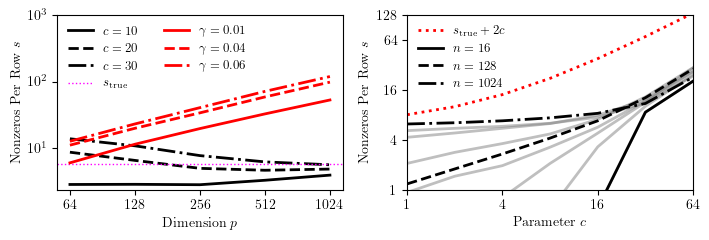

In [4]:
def test_2(c, p_line, data_type,seed=0):
    
    nnz      = np.zeros(len(p_line))
    nnz_true = np.zeros(len(p_line))

    # Metrics for sample-based run (method=1)
    # nnz_sample_avg = np.zeros(len(p_line))
    # nnz_sample_std = np.zeros(len(p_line))
    
    # gamma_set = np.zeros(len(p_line))

    for inx, p in enumerate(p_line):

        print('--> p',p)
        n = int(p / 2)  # Assuming n is half of p
        k = int(n / 2)  # Assuming k is half of n

        # Generate true covariance and data
        iC_true, C_true = make_cov(p, data_type=data_type,seed=inx)
        Y               = make_samples(cov=C_true, n=int(n), seed=inx)

        # Compute AQUIC estimate and metrics
        res_aquic     = compute_aquic(Y, c=c, k=k)
        met_aquic     = compute_metrics(res_aquic, C_true, iC_true, Y)
        s             = (np.count_nonzero(res_aquic.iC) - p) / p
        nnz[inx]      = s
        nnz_true[inx] = (np.count_nonzero(iC_true) - p) / p

        # # Sample-based run us n_sampling = 1000 x p 
        # n_s = n 
        # k_s = k 
        # nnzpr_set, nnzpr_actual, nnzpr_true,gamma = test_1(iC_true, C_true, n_s, k_s, c, inx)
        # nnz_sample_avg[inx] = np.mean(nnzpr_set)
        # nnz_sample_std[inx] = np.std(nnzpr_set)
        # gamma_set[inx]      = gamma

        # print('->', np.min(nnzpr_set) , np.mean(nnzpr_set),np.max(nnzpr_set))

    return (
        nnz,
        nnz_true
    )

def test_3(p, n, k, c_line, data_type,seed=0):
    
    # Generate true covariance and data
    iC_true, C_true = make_cov(p, data_type=data_type,seed=seed)
    Y               = make_samples(cov=C_true, n=int(n), seed=seed)

    nnz             = np.zeros(len(c_line))
    nnz_true        = np.zeros(len(c_line))

    # # Metrics for sample-based run (method=1)
    # nnz_sample_avg = np.zeros(len(c_line))
    # nnz_sample_std = np.zeros(len(c_line))
    
    gamma_set = np.zeros(len(c_line))

    for inx, c in enumerate(c_line):

        print('--> c',c)
        
        # Compute AQUIC estimate and metrics
        res_aquic     = compute_aquic(Y, c=c, k=k)
        met_aquic     = compute_metrics(res_aquic, C_true, iC_true, Y)
        s             = (np.count_nonzero(res_aquic.iC) - p) / p
        nnz[inx]      = s
        nnz_true[inx] = (np.count_nonzero(iC_true) - p) / p

        # # Sample-based run us n_sampling = 1000 x p 
        # n_s = n 
        # k_s = k 
        # nnzpr_set, nnzpr_actual, nnzpr_true,gamma = test_1(iC_true, C_true, n_s, k_s, c,inx)
        # nnz_sample_avg[inx] = np.mean(nnzpr_set)
        # nnz_sample_std[inx] = np.std(nnzpr_set)
        # gamma_set[inx] = gamma

        # print('->', np.min(nnzpr_set) , np.mean(nnzpr_set),np.max(nnzpr_set))

    return (
        nnz,
        nnz_true,
        # nnz_sample_avg,
        # nnz_sample_std
    )

def test_4(gamma, p_line, data_type,seed=0):
  
    nnz             = np.zeros(len(p_line))
    nnz_true        = np.zeros(len(p_line))

    # Metrics for sample-based run (method=1)
    nnz_sample_avg = np.zeros(len(p_line))
    nnz_sample_std = np.zeros(len(p_line))
    
    for inx, p in enumerate(p_line):

        print('--> p',p)
        n = int(p / 2)  # Assuming n is half of p
        k = int(n / 2)  # Assuming k is half of n

        # Generate true covariance and data
        iC_true, C_true = make_cov(p, data_type=data_type,seed=inx)
        Y               = make_samples(cov=C_true, n=int(n), seed=inx)

        # Compute AQUIC estimate and metrics
        res_aquic     = compute_aquic(Y, gamma=gamma, k=k, clip_gamma=False)
        met_aquic     = compute_metrics(res_aquic, C_true, iC_true, Y)
        s             = (np.count_nonzero(res_aquic.iC) - p) / p
        nnz[inx]      = s
        nnz_true[inx] = (np.count_nonzero(iC_true) - p) / p

    return (
        nnz,
        nnz_true,
    )

########################################
# Plot
########################################
fig, axs = make_plot(1,2,s=[1.2,1],sharex=False, sharey=False)
data_type   = 'cluster'
line_style  = ['-', '--', '-.', ':']
color_style = ['k', 'b', 'r', 'g']

########################################
inx = 0
########################################
p_line = np.array([64, 128, 256, 512, 1024])

c = 10
nnz, nnz_true = test_2(c=c, p_line=p_line, data_type=data_type,seed=0)
axs[0,inx].loglog(p_line,nnz, color="black", alpha=1.0, linestyle='-', marker='', linewidth=2, label=rf"$c={c}$")

c = 20
nnz, nnz_true = test_2(c=c, p_line=p_line, data_type=data_type,seed=0)
axs[0,inx].loglog(p_line,nnz, color="black", alpha=1.0, linestyle='--', marker='', linewidth=2, label=rf"$c={c}$")

c = 30
nnz, nnz_true = test_2(c=c, p_line=p_line, data_type=data_type,seed=0)
axs[0,inx].loglog(p_line,nnz, color="black", alpha=1.0, linestyle='-.', marker='', linewidth=2, label=rf"$c={c}$")

axs[0,inx].axhline(y=np.mean(nnz_true), color="magenta", alpha=1.0, linestyle=":", linewidth=1, label=r"$s_\text{true}$")

gamma = .01
nnz, nnz_true = test_4(gamma=gamma, p_line=p_line, data_type=data_type,seed=0)
axs[0,inx].loglog(p_line,nnz, color="red", alpha=1.0, linestyle='-', marker='', linewidth=2, label=rf"$\gamma={gamma:.2f}$")

gamma = .04
nnz, nnz_true = test_4(gamma=gamma, p_line=p_line, data_type=data_type,seed=0)
axs[0,inx].loglog(p_line,nnz, color="red", alpha=1.0, linestyle='--', marker='', linewidth=2, label=rf"$\gamma={gamma:.2f}$")

gamma = .06
nnz, nnz_true = test_4(gamma=gamma, p_line=p_line, data_type=data_type,seed=0)
axs[0,inx].loglog(p_line,nnz, color="red", alpha=1.0, linestyle='-.', marker='', linewidth=2, label=rf"$\gamma={gamma:.2f}$")

axs[0,inx].set_ylim([None,1e3])
axs[0,inx].set_xscale("log", base=2)
axs[0,inx].set_xticks(p_line)
axs[0,inx].set_xticklabels([str(int(x)) for x in p_line])

axs[0,inx].set_ylabel(r"Nonzeros Per Row $s$")
axs[0,inx].set_xlabel(r"Dimension $p$")
axs[0,inx].legend(loc='upper left',frameon=False, fontsize=9, ncol=2)
axs[0,inx].xaxis.minorticks_off()
axs[0,inx].yaxis.minorticks_off()

########################################
inx = inx + 1
########################################
p = 128

c_target_line = np.array([1,2,4,8,16,32,64])
iC_true, C_true = make_cov(p, data_type=data_type)
s_true = (np.count_nonzero(iC_true) - p) / p

n_set = [16,32,64,128,256,512,1024]
for i, n in enumerate(n_set):
    k = n / 2.0
    nnz, nnz_true = test_3(p,n,k,c_target_line, data_type,seed=i)

    axs[0,inx].loglog(c_target_line,nnz, color="gray", alpha=.5, linestyle='-',  marker='', linewidth=2 , zorder=1 , label=rf"_")
    print(" - n ", n, "nnz = ",nnz)

axs[0,inx].loglog(c_target_line,s_true +2*c_target_line , color="red", alpha=1, linestyle=":",  marker='', linewidth=2 , label=r"$s_\text{true}+2c$")

n = n_set[0]
k = n / 2.0
nnz, nnz_true = test_3(p,n,k,c_target_line, data_type,seed=0)
axs[0,inx].loglog(c_target_line,nnz, color="black", alpha=1, linestyle='-',  marker='', linewidth=2 , label=rf"$n={n:.0f}$")
print("nnz = ",nnz)

n = n_set[3]
k = n / 2.0
nnz, nnz_true = test_3(p,n,k,c_target_line, data_type,seed=0)
axs[0,inx].loglog(c_target_line,nnz, color="black", alpha=1, linestyle='--',  marker='', linewidth=2 , label=rf"$n={n:.0f}$")
print("nnz = ",nnz)

n = n_set[-1]
k = n / 2.0
nnz, nnz_true = test_3(p,n,k,c_target_line, data_type,seed=0)
axs[0,inx].loglog(c_target_line,nnz, color="black", alpha=1, linestyle='-.',  marker='', linewidth=2 , label=rf"$n={n:.0f}$")
print("nnz = ",nnz)

axs[0,inx].set_ylim([np.min(c_target_line),np.max(c_target_line)])
axs[0,inx].set_xlim([np.min(c_target_line),np.max(c_target_line)])
axs[0,inx].set_xticks(c_target_line)
axs[0,inx].set_yticks(c_target_line)
axs[0,inx].set_ylabel(c_target_line)
axs[0,inx].set_xlabel(c_target_line)

axs[0,inx].set_yscale("log", base=2)
axs[0,inx].set_xscale("log", base=2)

# Force tick labels to be plain numbers
y_line = [1,4,16,64,128]
axs[0,inx].set_yticks(y_line)
axs[0,inx].set_yticklabels([str(int(x)) for x in y_line])
axs[0,inx].set_ylim([min(y_line),max(y_line)])

x_line = [1,4,16,64]
axs[0,inx].set_xticks(x_line)
axs[0,inx].set_xticklabels([str(int(x)) for x in x_line])
axs[0,inx].set_xlim([min(x_line),max(x_line)])

axs[0,inx].set_ylabel(r"Nonzeros Per Row $s$")
axs[0,inx].set_xlabel(r"Parameter $c$")
axs[0,inx].legend(loc='upper left', frameon=False, fontsize=9, ncol=1)
axs[0,inx].xaxis.minorticks_off()
axs[0,inx].yaxis.minorticks_off()

print('s_true=',s_true)
print('nnz ',nnz)

fig.savefig("fig_3.png", dpi=300)

# Fig 4,5 & 5

In [5]:
def single_run(inx, n, dof, C_true, iC_true, u, just_run_aquic=True):

    p = C_true.shape[0]
    Y = make_samples(cov=C_true, n=int(n), seed=inx,df=dof)
        
    res_glasso = None
    res_quic   = None
    res_tiger  = None
    res_clime  = None
    res_aquic1 = None
    res_aquic2 = None
    res_aquic3 = None

    if just_run_aquic==False:
        # GLASSO-CV
        res_glasso = compute_glasso_cv(Y)

        # QUIC-CV
        if p < 2048:
            res_quic = compute_quic_cv(Y)

        # TIGER 
        if p < 1024:
            res_tiger = compute_tiger(Y)

        # CLIME  
        if p < 512:
            res_clime = compute_clime(Y)
    
    else:
        #AQUIC 
        k = n/u
        res_aquic1 = compute_aquic(Y,c=30,k=k)
        res_aquic2 = compute_aquic(Y,c=5 ,k=k)
        res_aquic3 = compute_aquic(Y,c=1 ,k=k)

    met_glasso = compute_metrics(res_glasso, C_true, iC_true, Y)
    met_quic   = compute_metrics(res_quic,   C_true, iC_true, Y)
    met_tiger  = compute_metrics(res_tiger,  C_true, iC_true, Y)
    met_clime  = compute_metrics(res_clime,  C_true, iC_true, Y)
    met_aquic1 = compute_metrics(res_aquic1, C_true, iC_true, Y)
    met_aquic2 = compute_metrics(res_aquic2, C_true, iC_true, Y)
    met_aquic3 = compute_metrics(res_aquic3, C_true, iC_true, Y)

    print(
        f"nnzpr:{np.count_nonzero(iC_true)/p:.1f} | "
        f"G[rt:{met_glasso.runtime:.2f}s nnz:{met_glasso.nnz:.0f} f1:{met_glasso.f1:.2f} iC:{met_glasso.err_iC:.2f} C:{met_glasso.err_C:.2f} kl:{met_glasso.kl:.2f}] | "
        f"Q[rt:{met_quic.runtime:.2f}s nnz:{met_quic.nnz:.0f} f1:{met_quic.f1:.2f} iC:{met_quic.err_iC:.2f} C:{met_quic.err_C:.2f} kl:{met_quic.kl:.2f}] | "
        f"T[rt:{met_tiger.runtime:.2f}s nnz:{met_tiger.nnz:.0f} f1:{met_tiger.f1:.2f} iC:{met_tiger.err_iC:.2f} C:{met_tiger.err_C:.2f} kl:{met_tiger.kl:.2f}] | "
        f"C[rt:{met_clime.runtime:.2f}s nnz:{met_clime.nnz:.0f} f1:{met_clime.f1:.2f} iC:{met_clime.err_iC:.2f} C:{met_clime.err_C:.2f} kl:{met_clime.kl:.2f}] | "
        f"A1[rt:{met_aquic1.runtime:.2f}s nnz:{met_aquic1.nnz:.0f} f1:{met_aquic1.f1:.2f} iC:{met_aquic1.err_iC:.2f} C:{met_aquic1.err_C:.2f} kl:{met_aquic1.kl:.2f}] | "
        f"A2[rt:{met_aquic2.runtime:.2f}s nnz:{met_aquic2.nnz:.0f} f1:{met_aquic2.f1:.2f} iC:{met_aquic2.err_iC:.2f} C:{met_aquic2.err_C:.2f} kl:{met_aquic2.kl:.2f}] | "
        f"A3[rt:{met_aquic3.runtime:.2f}s nnz:{met_aquic3.nnz:.0f} f1:{met_aquic3.f1:.2f} iC:{met_aquic3.err_iC:.2f} C:{met_aquic3.err_C:.2f} kl:{met_aquic3.kl:.2f}]"
    )
    return {
        'glasso': met_glasso,
        'quic':   met_quic,
        'tiger':  met_tiger,
        'clime':  met_clime,
        'aquic1': met_aquic1,
        'aquic2': met_aquic2,
        'aquic3': met_aquic3,
    }

def convert_to_dataframes(raw_data):
    out = {}
    # Use the methods in the first task result as reference.
    for method in raw_data[0]:
        # Get the metric names from the first non-None result.
        first_valid = next((ns for ns in raw_data[0][method] if ns is not None), None)
        if first_valid is None:
            continue
        metric_names = list(first_valid.__dict__.keys())
        method_metrics = {}
        # For each metric, build one column per task.
        for metric in metric_names:
            # Each column corresponds to one task (one n_ratio value)
            cols = [
                np.array([ns.__dict__[metric] if ns is not None else np.nan for ns in task[method]])
                for task in raw_data
            ]
            # Stack columns horizontally so that rows are iterations.
            matrix = np.column_stack(cols)
            method_metrics[metric] = pd.DataFrame(matrix, columns=list(range(len(raw_data))))
        out[method] = SimpleNamespace(**method_metrics)
    return out

# using 'just_run_aquic' to just run aquic ( this is much faster than the full run)
just_run_aquic=True
os.makedirs(f"./results/synthetic", exist_ok=True)

###########################
# Fixed p = 128, change n/p = [1/8, ... 2]/128 (Gaussian)
###########################
print(f'\n############## \n# Error 1 \n##############')
for u in [1,2,4,6]:

    if just_run_aquic == True:
        file_name = f'err1_aquic_k{u}'+'.pkl'
    else:
        file_name = f'err1.pkl'

    full_path = f"./results/synthetic/"+file_name
    if os.path.exists(full_path):
        print("File exists, skipping:", full_path)
        continue
    else:
        p  = 128
        N  = 10

        os.environ["PYTHONWARNINGS"] = "ignore"  # Applies to all subprocesses
        data_type_list = ["cluster", "band", "hub"]

        dataframes = {}
        for data_type in data_type_list:
            print("Processing data type:", data_type)
            
            # Generate covariance matrix and samples.
            iC_true, C_true = make_cov(p, data_type=data_type, seed=24)

            # Define the n_ratio values.
            n_ratio_set = np.logspace(np.log2(1./8.), np.log2(2.0), num=10,base=2)
            
            # For each n_ratio value, run N iterations in parallel.
            raw_data = []  # Will be a list (length = number of n_ratio values).
            for n_ratio in n_ratio_set:
                print(f"Running n_ratio={n_ratio} iterations")

                n = int(n_ratio * p)
                dof = np.inf #t distirbtion dof->inf than gaussian

                task_input_list = [(inx, n, dof, C_true, iC_true, u, just_run_aquic) for inx in range(N)]
                single_results = []
                for args in tqdm(task_input_list, total=N, desc=f"n_ratio={n_ratio} iterations"):
                    result = single_run(*args)
                    single_results.append(result)
                
                # For each method, we now want a list of N results.
                task_result = {method: [res[method] for res in single_results]
                            for method in single_results[0]}
                raw_data.append(task_result)
            
            # Convert the raw_data (list per n_ratio value) into matrices per metric.
            dataframes[data_type] = convert_to_dataframes(raw_data)
        
        pd.to_pickle([n_ratio_set,dataframes], full_path)

###########################
# Fixed n/p = 0.5, change in p = [64,...,2048] (Gaussian)
###########################
print(f'\n############## \n# Error 2 \n##############')
for u in [1,2,4,6]:

    if just_run_aquic == True:
        file_name = f'err2_aquic_k{u}'+'.pkl'
    else:
        file_name = f'err2.pkl'

    full_path = f"./results/synthetic/"+file_name
    if os.path.exists(full_path):
        print("File exists, skipping:", full_path)
        continue
    else:
        r = 2
        N = 10

        os.environ["PYTHONWARNINGS"] = "ignore" 
        data_type_list = ["cluster", "band", "hub"]

        dataframes = {}
        for data_type in data_type_list:
            print("\n Processing data type:", data_type)
            
            # Define the n_ratio values.
            p_set = [64,128,256,512,1024,2048]

            # For each n_ratio value, run 100 iterations in parallel.
            raw_data = []  # Will be a list (length = number of n_ratio values).
            for p in p_set:
                # Generate covariance matrix and samples.
                iC_true, C_true = make_cov(p, data_type=data_type, seed=24)
                n = int(p/r)
                dof = np.inf #t distirbtion dof->inf than gaussian
                task_input_list = [(inx, n, dof, C_true, iC_true, u, just_run_aquic) for inx in range(N)]
                single_results = []
                for args in tqdm(task_input_list, total=N, desc=f"p={p} iterations"):
                    result = single_run(*args)
                    single_results.append(result)
                
                # For each method, we now want a list of 100 results.
                task_result = {method: [res[method] for res in single_results]
                            for method in single_results[0]}
                raw_data.append(task_result)
            
            # Convert the raw_data (list per n_ratio value) into matrices per metric.
            dataframes[data_type] = convert_to_dataframes(raw_data)

        pd.to_pickle([n_ratio_set,dataframes], full_path)

###########################
# Fixed p=128 and n=p/2, change in dof = [2,4,8,16,32] (t-distribution)
###########################
print(f'\n############## \n# Error 3 \n##############')
for u in [1,2,4,6]:

    if just_run_aquic == True:
        file_name = f'err3_aquic_k{u}'+'.pkl'
    else:
        file_name = f'err3.pkl'

    full_path = f"./results/synthetic/"+file_name
    if os.path.exists(full_path):
        print("File exists, skipping:", full_path)
        continue
    else:
        
        p  = 128
        N  = 10

        os.environ["PYTHONWARNINGS"] = "ignore"  # Applies to all subprocesses
        data_type_list = ["cluster", "band", "hub"]

        dataframes = {}
        for data_type in data_type_list:
            print("Processing data type:", data_type)
            
            # Generate covariance matrix and samples.
            iC_true, C_true = make_cov(p, data_type=data_type, seed=24)
            
            # Define the n_ratio values.
            dof_set = [3,4,5,6,10,20]

            # For each n_ratio value, run 100 iterations in parallel.
            raw_data = []  # Will be a list (length = number of n_ratio values).
            for dof in dof_set:
                print(f"Running dof_={dof} iterations")

                n = p/2
                task_input_list = [(inx, n, dof, C_true, iC_true, u, just_run_aquic) for inx in range(N)]

                single_results = []
                for args in tqdm(task_input_list, total=N, desc=f"dof_={dof} iterations"):
                    result = single_run(*args)
                    single_results.append(result)
                
                # For each method, we now want a list of 100 results.
                task_result = {method: [res[method] for res in single_results]
                            for method in single_results[0]}
                raw_data.append(task_result)
            
            # Convert the raw_data (list per n_ratio value) into matrices per metric.
            dataframes[data_type] = convert_to_dataframes(raw_data)

        file_name = f'err3_aquic_k{u}'+'.pkl'
        pd.to_pickle([dof_set,dataframes], file_name)


############## 
# Error 1 
##############
File exists, skipping: ./results/synthetic/err1_aquic_k1.pkl
File exists, skipping: ./results/synthetic/err1_aquic_k2.pkl
File exists, skipping: ./results/synthetic/err1_aquic_k4.pkl
File exists, skipping: ./results/synthetic/err1_aquic_k6.pkl

############## 
# Error 2 
##############
File exists, skipping: ./results/synthetic/err2_aquic_k1.pkl
File exists, skipping: ./results/synthetic/err2_aquic_k2.pkl
File exists, skipping: ./results/synthetic/err2_aquic_k4.pkl
File exists, skipping: ./results/synthetic/err2_aquic_k6.pkl

############## 
# Error 3 
##############
File exists, skipping: ./results/synthetic/err3_aquic_k1.pkl
File exists, skipping: ./results/synthetic/err3_aquic_k2.pkl
File exists, skipping: ./results/synthetic/err3_aquic_k4.pkl
File exists, skipping: ./results/synthetic/err3_aquic_k6.pkl


Saving figure to fig_err1.png
Figure size (width x height): (10.799999999999999, 12.5) aspect: 1.1574074074074074


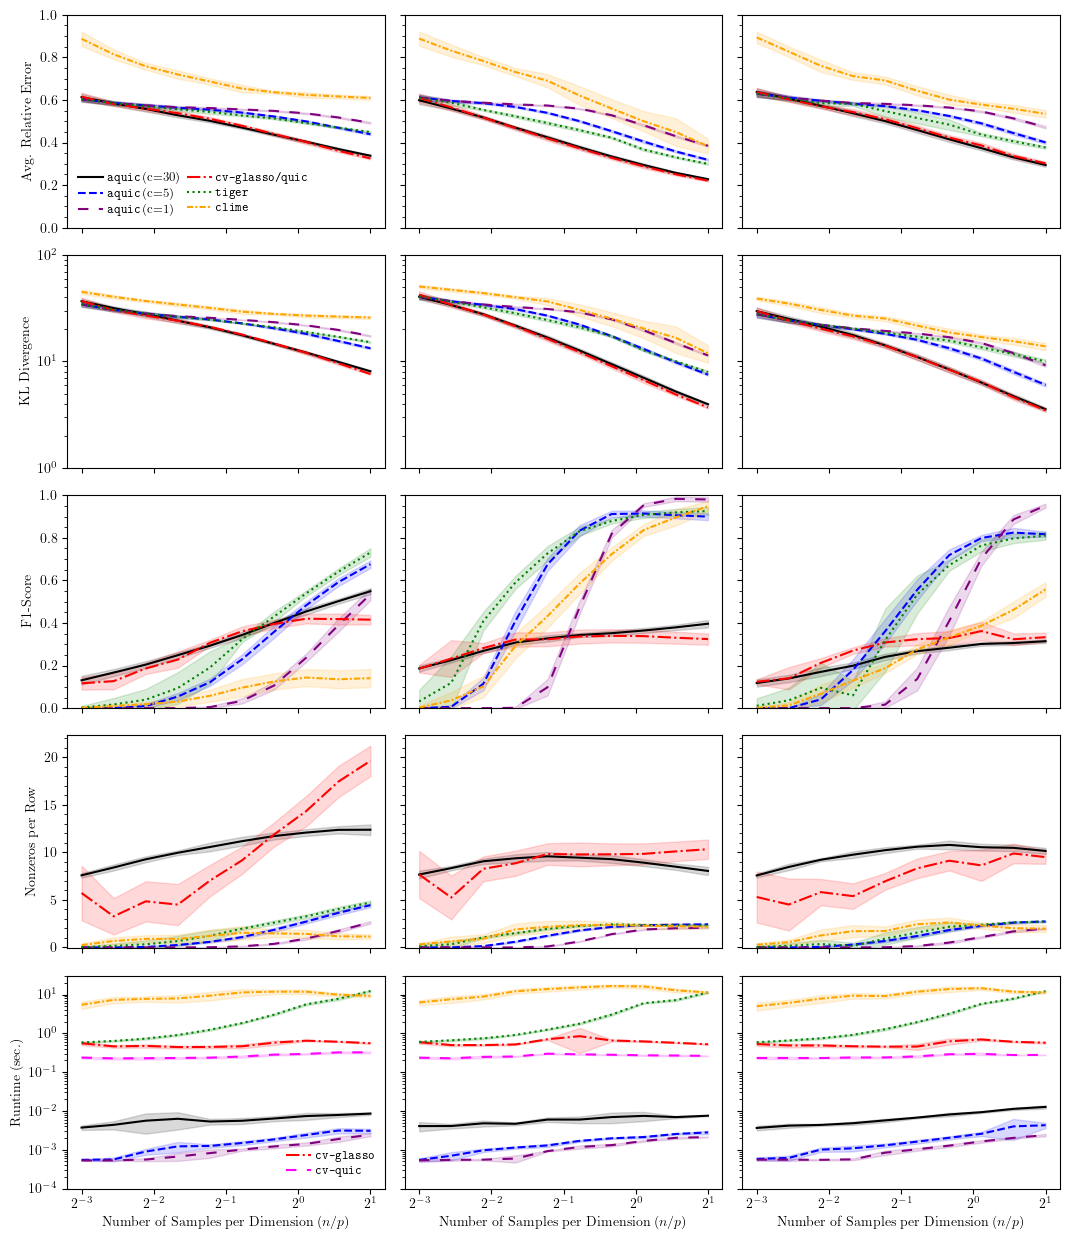

In [51]:
folder_name = "./results/synthetic"
x_line, dataframe       = pd.read_pickle(f"{folder_name}/err1.pkl")
_,      dataframe_aquic = pd.read_pickle(f"{folder_name}/err1_aquic_k2.pkl")

line_style = [(0, (5, 5)), "-", "--", "-.", ":", (0, (3, 1, 1, 1))]
fig, axs   = make_plot(5, 3, s=[1.2, 1], sharex=True, sharey="row")

line_alpha, fill_alpha, std_band = 1.0, 0.15, 1
data_types = ["cluster", "band", "hub"]

# aquic1->c=30 aquic2->c=5 aquic3->c=1
aquic_id1, aquic_id1_label = "aquic1", r"\texttt{aquic}\,(c=30)"
aquic_id2, aquic_id2_label = "aquic2", r"\texttt{aquic}\,(c=5)"
aquic_id3, aquic_id3_label = "aquic3", r"\texttt{aquic}\,(c=1)"

def mean_std(obj, attr, semilog=False):
    x = getattr(obj, attr)
    m, v = x.mean(0), x.std(0) * std_band
    return m, v

i = 0
# Avg Relative Error (avg of C and iC)
for j, dt in enumerate(data_types):
    for key, col, ls, lab in [
        (aquic_id1, "black",   line_style[1], aquic_id1_label),
        (aquic_id2, "blue",    line_style[2], aquic_id2_label),
        (aquic_id3, "purple",  line_style[0], aquic_id3_label),
        ("glasso",  "red",     line_style[3], r"$\texttt{cv-glasso/quic}$"),
        ("tiger",   "green",   line_style[4], r"$\texttt{tiger}$"),
        ("clime",   "orange",  line_style[5], r"$\texttt{clime}$"),
    ]:
        src = dataframe_aquic if "aquic" in key else dataframe
        obj = src[dt][key]
        m = (obj.err_iC.mean(0) + obj.err_C.mean(0)) / 2
        v = ((obj.err_iC.std(0) + obj.err_C.std(0)) / 2) * std_band
        axs[i, j].plot(x_line, m, color=col, linestyle=ls, label=lab, alpha=line_alpha)
        axs[i, j].fill_between(x_line, m + v, m - v, alpha=fill_alpha, color=col)

axs[i, 0].legend(
    loc="lower left",
    frameon=False,
    fontsize=9, 
    ncol=2,
    labelspacing=0.3, 
    handletextpad=0.3,
    columnspacing=0.5
)

axs[i, 0].set_ylim([0, 1e0])
axs[i, 0].set_ylabel(r"Avg. Relative Error")
axs[i, 0].minorticks_on()

i += 1
# KL Divergence
for j, dt in enumerate(data_types):
    for key, col, ls, lab in [
        (aquic_id1, "black",  line_style[1], aquic_id1_label),
        (aquic_id2, "blue",   line_style[2], aquic_id2_label),
        (aquic_id3, "purple", line_style[0], aquic_id3_label),
        ("glasso",  "red",    line_style[3], r"$\texttt{cv-glasso}$"),
        ("tiger",   "green",  line_style[4], r"$\texttt{tiger}$"),
        ("clime",   "orange", line_style[5], r"$\texttt{clime}$"),
    ]:
        src = dataframe_aquic if "aquic" in key else dataframe
        obj = src[dt][key]
        m, v = obj.kl.mean(0), obj.kl.std(0) * std_band
        axs[i, j].semilogy(x_line, m, color=col, linestyle=ls, label=lab, alpha=line_alpha)
        axs[i, j].fill_between(x_line, m + v, m - v, alpha=fill_alpha, color=col)

axs[i, 0].set_ylim([1e0, 1e2])
axs[i, 0].set_ylabel(r"KL Divergence")
axs[i, 0].minorticks_on()

i += 1
# F1 Score
for j, dt in enumerate(data_types):
    for key, col, ls, lab in [
        (aquic_id1, "black",  line_style[1], aquic_id1_label),
        (aquic_id2, "blue",   line_style[2], aquic_id2_label),
        (aquic_id3, "purple", line_style[0], aquic_id3_label),
        ("glasso",  "red",    line_style[3], r"$\texttt{cv-glasso}$"),
        ("tiger",   "green",  line_style[4], r"$\texttt{tiger}$"),
        ("clime",   "orange", line_style[5], r"$\texttt{clime}$"),
    ]:
        src = dataframe_aquic if "aquic" in key else dataframe
        obj = src[dt][key]
        m, v = obj.f1.mean(0), obj.f1.std(0) * std_band
        axs[i, j].semilogx(x_line, m, color=col, linestyle=ls, label=lab, alpha=line_alpha)
        axs[i, j].fill_between(x_line, m + v, m - v, alpha=fill_alpha, color=col)

axs[i, 0].set_ylabel(r"F1-Score")
axs[i, 0].set_ylim([0, 1])
axs[i, 0].minorticks_on()

i += 1
# Nonzeros per Row
for j, dt in enumerate(data_types):
    for key, col, ls, lab in [
        (aquic_id1, "black",  line_style[1], aquic_id1_label),
        (aquic_id2, "blue",   line_style[2], aquic_id2_label),
        (aquic_id3, "purple", line_style[0], aquic_id3_label),
        ("glasso",  "red",    line_style[3], r"$\texttt{cv-glasso}$"),
        ("tiger",   "green",  line_style[4], r"$\texttt{tiger}$"),
        ("clime",   "orange", line_style[5], r"$\texttt{clime}$"),
    ]:
        src = dataframe_aquic if "aquic" in key else dataframe
        obj = src[dt][key]
        m, v = obj.nnz.mean(0), obj.nnz.std(0) * std_band
        axs[i, j].semilogx(x_line, m, color=col, linestyle=ls, label=lab, alpha=line_alpha)
        axs[i, j].fill_between(x_line, m + v, m - v, alpha=fill_alpha, color=col)

axs[i, 0].set_ylim([-.1, None])
axs[i, 0].set_ylabel(r"Nonzeros per Row")
axs[i, 0].minorticks_on()

i += 1
# Runtime
threshold = 5
for j, dt in enumerate(data_types):
    for key, col, ls, lab in [
        (aquic_id1, "black",  line_style[1], ""),
        (aquic_id2, "blue",   line_style[2], ""),
        (aquic_id3, "purple", line_style[0], ""),
        ("glasso",  "red",    line_style[3], r"$\texttt{cv-glasso}$"),
        ("quic",    "magenta", line_style[0],r"$\texttt{cv-quic}$"), 
        ("tiger",   "green",  line_style[4], ""),
        ("clime",   "orange", line_style[5], ""),
    ]:
        src = dataframe_aquic if "aquic" in key else dataframe
        rt  = src[dt][key].runtime.astype(float).mask(lambda x: x.gt(threshold * x.min(0)), np.nan)
        m, v = rt.mean(0), rt.std(0) * std_band
        axs[i, j].loglog(x_line, m, color=col, linestyle=ls, label=lab, alpha=line_alpha)
        axs[i, j].fill_between(x_line, m + v, m - v, alpha=fill_alpha, color=col)
    axs[i, j].set_xlabel(r"Number of Samples per Dimension ($n/p$)")

axs[i, 0].set_ylim([1e-4, None])
axs[i, 0].set_ylabel(r"Runtime (sec.)")
axs[i, 0].minorticks_on()
axs[i, 0].set_xscale("log", base=2)
axs[i, 0].legend(loc="lower right", frameon=False, fontsize=9, ncol=1, labelspacing=0.3, handletextpad=0.3)

fig_name = "fig_err1.png"
print("Saving figure to", fig_name)
fig.savefig(fig_name, dpi=300)
w, h = fig.get_size_inches()
print("Figure size (width x height):", (w, h), "aspect:", h / w)

Saving figure to fig_err2.png
Figure size (width x height): (10.799999999999999, 12.5) aspect: 1.1574074074074074


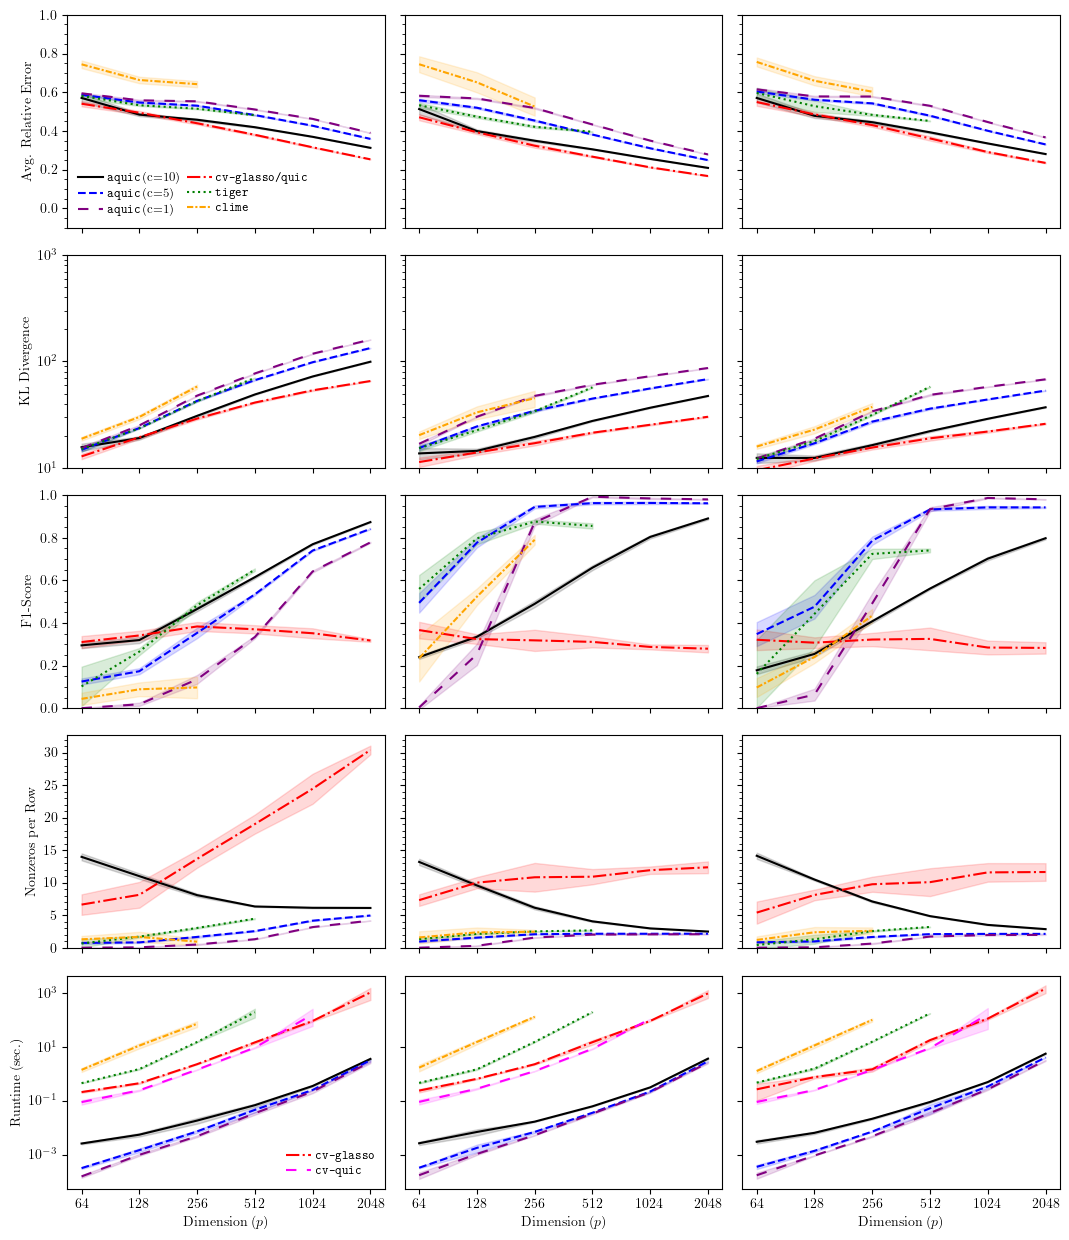

In [52]:
folder_name = "./results/synthetic"
x_line, dataframe       = pd.read_pickle(f"{folder_name}/err2.pkl")
_,      dataframe_aquic = pd.read_pickle(f"{folder_name}/err2_aquic_k2.pkl")

line_style = [(0, (5, 5)), "-", "--", "-.", ":", (0, (3, 1, 1, 1))]
fig, axs   = make_plot(5, 3, s=[1.2, 1], sharex=True, sharey="row")

line_alpha, fill_alpha, std_band = 1.0, 0.15, 1
data_types = ["cluster", "band", "hub"]

# aquic1->c=10 aquic2->c=5 aquic3->c=1
aquic_id1, aquic_id1_label = "aquic1", r"\texttt{aquic}\,(c=10)"
aquic_id2, aquic_id2_label = "aquic2", r"\texttt{aquic}\,(c=5)"
aquic_id3, aquic_id3_label = "aquic3", r"\texttt{aquic}\,(c=1)"

i = 0
# Avg Relative Error (avg of C and iC)
for j, dt in enumerate(data_types):
    for key, col, ls, lab in [
        (aquic_id1, "black",  line_style[1], aquic_id1_label),
        (aquic_id2, "blue",   line_style[2], aquic_id2_label),
        (aquic_id3, "purple", line_style[0], aquic_id3_label),
        ("glasso",  "red",    line_style[3], r"$\texttt{cv-glasso/quic}$"),
        ("tiger",   "green",  line_style[4], r"$\texttt{tiger}$"),
        ("clime",   "orange", line_style[5], r"$\texttt{clime}$"),
    ]:
        src = dataframe_aquic if "aquic" in str(key) else dataframe
        obj = src[dt][key]
        m = (obj.err_iC.mean(0) + obj.err_C.mean(0)) / 2
        v = ((obj.err_iC.std(0) + obj.err_C.std(0)) / 2) * std_band
        axs[i, j].plot(x_line, m, color=col, linestyle=ls, label=lab, alpha=line_alpha)
        axs[i, j].fill_between(x_line, m + v, m - v, alpha=fill_alpha, color=col)

axs[i, 0].legend(
    loc="lower left",
    frameon=False,
    fontsize=9, 
    ncol=2,
    labelspacing=0.3, 
    handletextpad=0.3,
    columnspacing=0.5
)
axs[i, 0].set_ylim([-.1, 1e0])
axs[i, 0].set_ylabel(r"Avg. Relative Error")
axs[i, 0].minorticks_on()

i += 1
# KL Divergence
for j, dt in enumerate(data_types):
    for key, col, ls, lab in [
        (aquic_id1, "black",  line_style[1], aquic_id1_label),
        (aquic_id2, "blue",   line_style[2], aquic_id2_label),
        (aquic_id3, "purple", line_style[0], aquic_id3_label),
        ("glasso",  "red",    line_style[3], r"$\texttt{cv-glasso}$"),
        ("tiger",   "green",  line_style[4], r"$\texttt{tiger}$"),
        ("clime",   "orange", line_style[5], r"$\texttt{clime}$"),
    ]:
        src = dataframe_aquic if "aquic" in str(key) else dataframe
        obj = src[dt][key]
        m, v = obj.kl.mean(0), obj.kl.std(0) * std_band
        axs[i, j].semilogy(x_line, m, color=col, linestyle=ls, label=lab, alpha=line_alpha)
        axs[i, j].fill_between(x_line, m + v, m - v, alpha=fill_alpha, color=col)

axs[i, 0].set_ylim([1e1, 1e3])
axs[i, 0].set_ylabel(r"KL Divergence")
axs[i, 0].minorticks_on()

i += 1
# F1 Score
for j, dt in enumerate(data_types):
    for key, col, ls, lab in [
        (aquic_id1, "black",  line_style[1], aquic_id1_label),
        (aquic_id2, "blue",   line_style[2], aquic_id2_label),
        (aquic_id3, "purple", line_style[0], aquic_id3_label),
        ("glasso",  "red",    line_style[3], r"$\texttt{cv-glasso}$"),
        ("tiger",   "green",  line_style[4], r"$\texttt{tiger}$"),
        ("clime",   "orange", line_style[5], r"$\texttt{clime}$"),
    ]:
        src = dataframe_aquic if "aquic" in str(key) else dataframe
        obj = src[dt][key]
        m, v = obj.f1.mean(0), obj.f1.std(0) * std_band
        axs[i, j].semilogx(x_line, m, color=col, linestyle=ls, label=lab, alpha=line_alpha)
        axs[i, j].fill_between(x_line, m + v, m - v, alpha=fill_alpha, color=col)

axs[i, 0].set_ylabel(r"F1-Score")
axs[i, 0].set_ylim([0, 1])
axs[i, 0].minorticks_on()

i += 1
# Nonzeros per Row
for j, dt in enumerate(data_types):
    for key, col, ls, lab in [
        (aquic_id1, "black",  line_style[1], aquic_id1_label),
        (aquic_id2, "blue",   line_style[2], aquic_id2_label),
        (aquic_id3, "purple", line_style[0], aquic_id3_label),
        ("glasso",  "red",    line_style[3], r"$\texttt{cv-glasso}$"),
        ("tiger",   "green",  line_style[4], r"$\texttt{tiger}$"),
        ("clime",   "orange", line_style[5], r"$\texttt{clime}$"),
    ]:
        src = dataframe_aquic if "aquic" in str(key) else dataframe
        obj = src[dt][key]
        m, v = obj.nnz.mean(0), obj.nnz.std(0) * std_band
        axs[i, j].semilogx(x_line, m, color=col, linestyle=ls, label=lab, alpha=line_alpha)
        axs[i, j].fill_between(x_line, m + v, m - v, alpha=fill_alpha, color=col)

axs[i, 0].set_ylim([-.1, None])
axs[i, 0].set_ylabel(r"Nonzeros per Row")
axs[i, 0].minorticks_on()

i += 1
# Runtime
threshold = 5
for j, dt in enumerate(data_types):
    for key, col, ls, lab in [
        (aquic_id1, "black",   line_style[1], ""),
        (aquic_id2, "blue",    line_style[2], ""),
        (aquic_id3, "purple", line_style[0], ""),
        ("glasso",  "red",     line_style[3], r"$\texttt{cv-glasso}$"),
        ("quic",    "magenta", line_style[0], r"$\texttt{cv-quic}$"),
        ("tiger",   "green",   line_style[4], ""),
        ("clime",   "orange",  line_style[5], ""),
    ]:
        src = dataframe_aquic if "aquic" in str(key) else dataframe
        rt  = src[dt][key].runtime.astype(float).mask(lambda x: x.gt(threshold * x.min(0)), np.nan)
        m, v = rt.mean(0), rt.std(0) * std_band
        axs[i, j].loglog(x_line, m, color=col, linestyle=ls, label=lab, alpha=line_alpha)
        axs[i, j].fill_between(x_line, m + v, m - v, alpha=fill_alpha, color=col)
    
    axs[i, j].set_xscale("log", base=2)
    axs[i, j].set_xticks(x_line)
    axs[i, j].xaxis.set_major_formatter(ScalarFormatter())
    axs[i, j].ticklabel_format(axis="x", style="plain")
    axs[i, j].set_xlabel(r"Dimension ($p$)")

axs[i, 0].set_ylabel(r"Runtime (sec.)")
axs[i, 0].minorticks_on()

axs[i, 0].legend(loc="lower right", frameon=False, fontsize=9, ncol=1, labelspacing=0.3, handletextpad=0.3)

fig_name = "fig_err2.png"
print("Saving figure to", fig_name)
fig.savefig(fig_name, dpi=300)
w, h = fig.get_size_inches()
print("Figure size (width x height):", (w, h), "aspect:", h / w)

Saving figure to fig_err3.png
Figure size (width x height): (10.799999999999999, 7.5) aspect: 0.6944444444444445


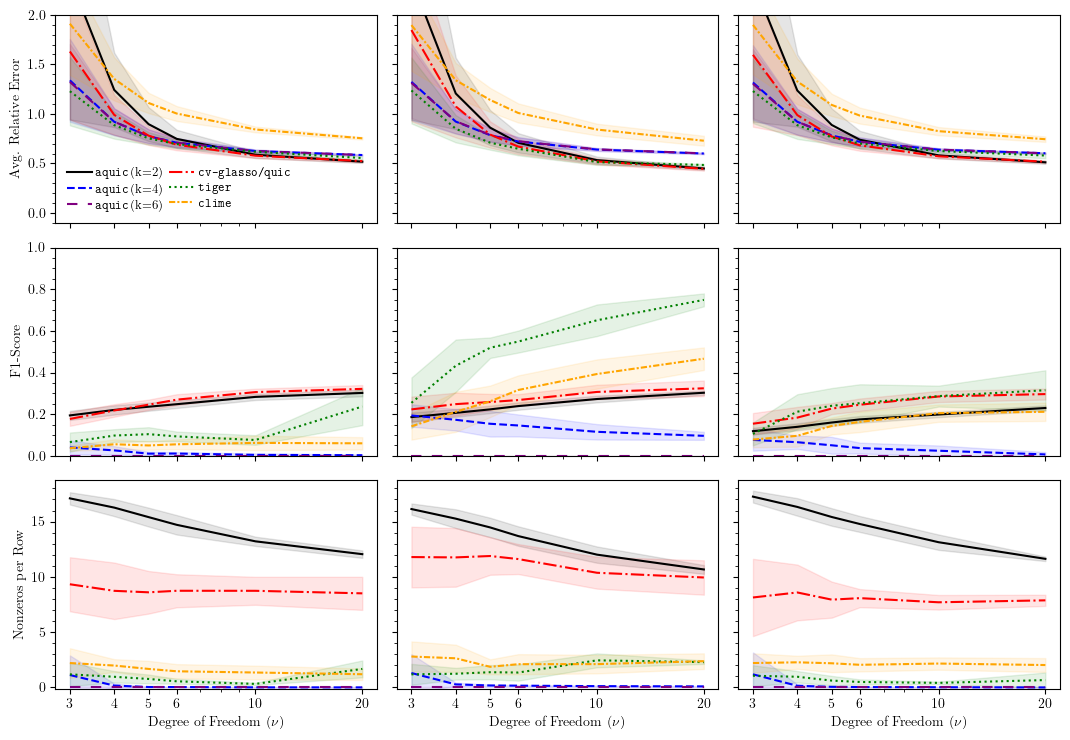

In [53]:
folder_name = "./results/synthetic"
x_line, dataframe          = pd.read_pickle(f"{folder_name}/err3.pkl")
_,      dataframe_aquic_k2 = pd.read_pickle(f"{folder_name}/err3_aquic_k2.pkl")
_,      dataframe_aquic_k4 = pd.read_pickle(f"{folder_name}/err3_aquic_k4.pkl")
_,      dataframe_aquic_k6 = pd.read_pickle(f"{folder_name}/err3_aquic_k6.pkl")

line_style = [(0, (5, 5)), "-", "--", "-.", ":", (0, (3, 1, 1, 1))]
fig, axs   = make_plot(3, 3, s=[1.2, 1], sharex=True, sharey="row")

line_alpha, fill_alpha, std_band = 1.0, 0.1, 1
data_types = ["cluster", "band", "hub"]

aquic_id1, aquic_id1_label = "aquic1", r"\texttt{aquic}\,(k=2)" # c=30
aquic_id2, aquic_id2_label = "aquic2", r"\texttt{aquic}\,(k=4)" # c=30
aquic_id3, aquic_id3_label = "aquic3", r"\texttt{aquic}\,(k=6)" # c=30

i = 0
# Avg Relative Error (avg of C and iC)
for j, dt in enumerate(data_types):
    for src, key, col, ls, lab in [
        (dataframe_aquic_k2, aquic_id1, "black",     line_style[1], aquic_id1_label),
        (dataframe_aquic_k4, aquic_id2, "blue",      line_style[2], aquic_id2_label),
        (dataframe_aquic_k6, aquic_id3, "purple",    line_style[0], aquic_id3_label),
        (dataframe,          "glasso",  "red",     line_style[3], r"$\texttt{cv-glasso/quic}$"),
        (dataframe,          "tiger",   "green",   line_style[4], r"$\texttt{tiger}$"),
        (dataframe,          "clime",   "orange",  line_style[5], r"$\texttt{clime}$"),
    ]:
        obj = src[dt][key]
        m = (obj.err_iC.mean(0) + obj.err_C.mean(0)) / 2
        v = ((obj.err_iC.std(0) + obj.err_C.std(0)) / 2) * std_band
        axs[i, j].plot(x_line, m, color=col, linestyle=ls, label=lab, alpha=line_alpha)
        axs[i, j].fill_between(x_line, m + v, m - v, alpha=fill_alpha, color=col)

axs[i, 0].legend(
    loc="lower left",
    frameon=False,
    fontsize=9, 
    ncol=2,
    labelspacing=0.3, 
    handletextpad=0.3,
    columnspacing=0.5
)

axs[i, 0].set_ylim([-.1, 2e0])
axs[i, 0].set_ylabel(r"Avg. Relative Error")
axs[i, 0].minorticks_on()

i += 1
# F1 Score
for j, dt in enumerate(data_types):
    for src, key, col, ls, lab in [
        (dataframe_aquic_k2, aquic_id1, "black",   line_style[1], aquic_id1_label),
        (dataframe_aquic_k4, aquic_id2, "blue",    line_style[2], aquic_id2_label),
        (dataframe_aquic_k6, aquic_id3, "purple",  line_style[0], aquic_id3_label),
        (dataframe,         "glasso",  "red",      line_style[3], r"$\texttt{glasso}$"),
        (dataframe,         "tiger",   "green",    line_style[4], r"$\texttt{tiger}$"),
        (dataframe,         "clime",   "orange",   line_style[5], r"$\texttt{clime}$"),
    ]:
        obj = src[dt][key]
        m, v = obj.f1.mean(0), obj.f1.std(0) * std_band
        axs[i, j].semilogx(x_line, m, color=col, linestyle=ls, label=lab, alpha=line_alpha)
        axs[i, j].fill_between(x_line, m + v, m - v, alpha=fill_alpha, color=col)

axs[i, 0].set_ylabel(r"F1-Score")
axs[i, 0].set_ylim([0, 1])
axs[i, 0].minorticks_on()

i += 1
# Nonzeros per Row
for j, dt in enumerate(data_types):
    for src, key, col, ls, lab in [
        (dataframe_aquic_k2, aquic_id1, "black",   line_style[1], aquic_id1_label),
        (dataframe_aquic_k4, aquic_id2, "blue",    line_style[2], aquic_id2_label),
        (dataframe_aquic_k6, aquic_id3, "purple",  line_style[0], aquic_id3_label),
        (dataframe,         "glasso",  "red",      line_style[3], r"$\texttt{glasso}$"),
        (dataframe,         "tiger",   "green",    line_style[4], r"$\texttt{tiger}$"),
        (dataframe,         "clime",   "orange",   line_style[5], r"$\texttt{clime}$"),
    ]:
        obj = src[dt][key]
        m, v = obj.nnz.mean(0), obj.nnz.std(0) * std_band
        axs[i, j].semilogx(x_line, m, color=col, linestyle=ls, label=lab, alpha=line_alpha)
        axs[i, j].fill_between(x_line, m + v, m - v, alpha=fill_alpha, color=col)

        axs[i, j].set_xlabel(r'Degree of Freedom ($\nu$)') 
        axs[i, j].set_xticks(x_line) 
        axs[i, j].get_xaxis().set_major_formatter(ScalarFormatter()) 
        axs[i, j].ticklabel_format(style='plain', axis='x') # force plain

axs[i, 0].set_ylim([-.1, None])
axs[i, 0].set_ylabel(r"Nonzeros per Row")
axs[i, 0].minorticks_on()

fig_name = "fig_err3.png"
print("Saving figure to", fig_name)
fig.savefig(fig_name, dpi=300)
w, h = fig.get_size_inches()
print("Figure size (width x height):", (w, h), "aspect:", h / w)